In [1]:
# import the packages
import os
from omigo_core import dataframe
from omigo_hydra import hydra
from omigo_ext import graph_ext

In [2]:
# read data. this is the famouse iris dataset
# the read() method should be used in general that takes tsv or gz compressed tsv
# x = hydra.read("/path/to/tsv-file.tsv.gz")
# or
# x = hydra.read("s3://bucket/path/to/tsv-file.tsv.gz")
x = hydra.read(os.getcwd() + "/../data/iris.tsv.gz")

[WARN ONCE ONLY]: read_file_contents_as_textis Deprecated. Use read_text_file


In [3]:
# show raw data
x.sample_n(10).to_df(5)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,2.5,3.0,1.1,Iris-versicolor
1,7.3,2.9,6.3,1.8,Iris-virginica
2,5.4,3.7,1.5,0.2,Iris-setosa
3,5.6,3.0,4.5,1.5,Iris-versicolor
4,7.4,2.8,6.1,1.9,Iris-virginica


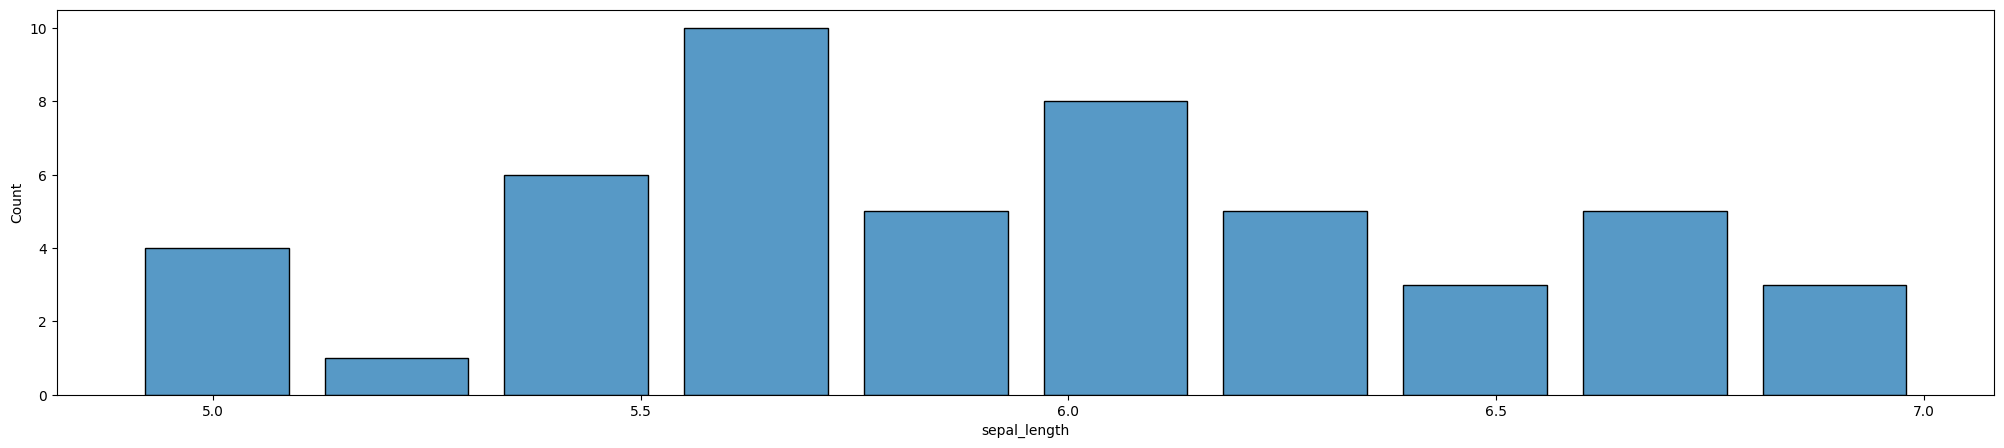

In [4]:
# simple histogram on columns
x \
    .eq_str("class", "Iris-versicolor") \
    .extend_class(graph_ext.VisualDF).histogram("sepal_length")

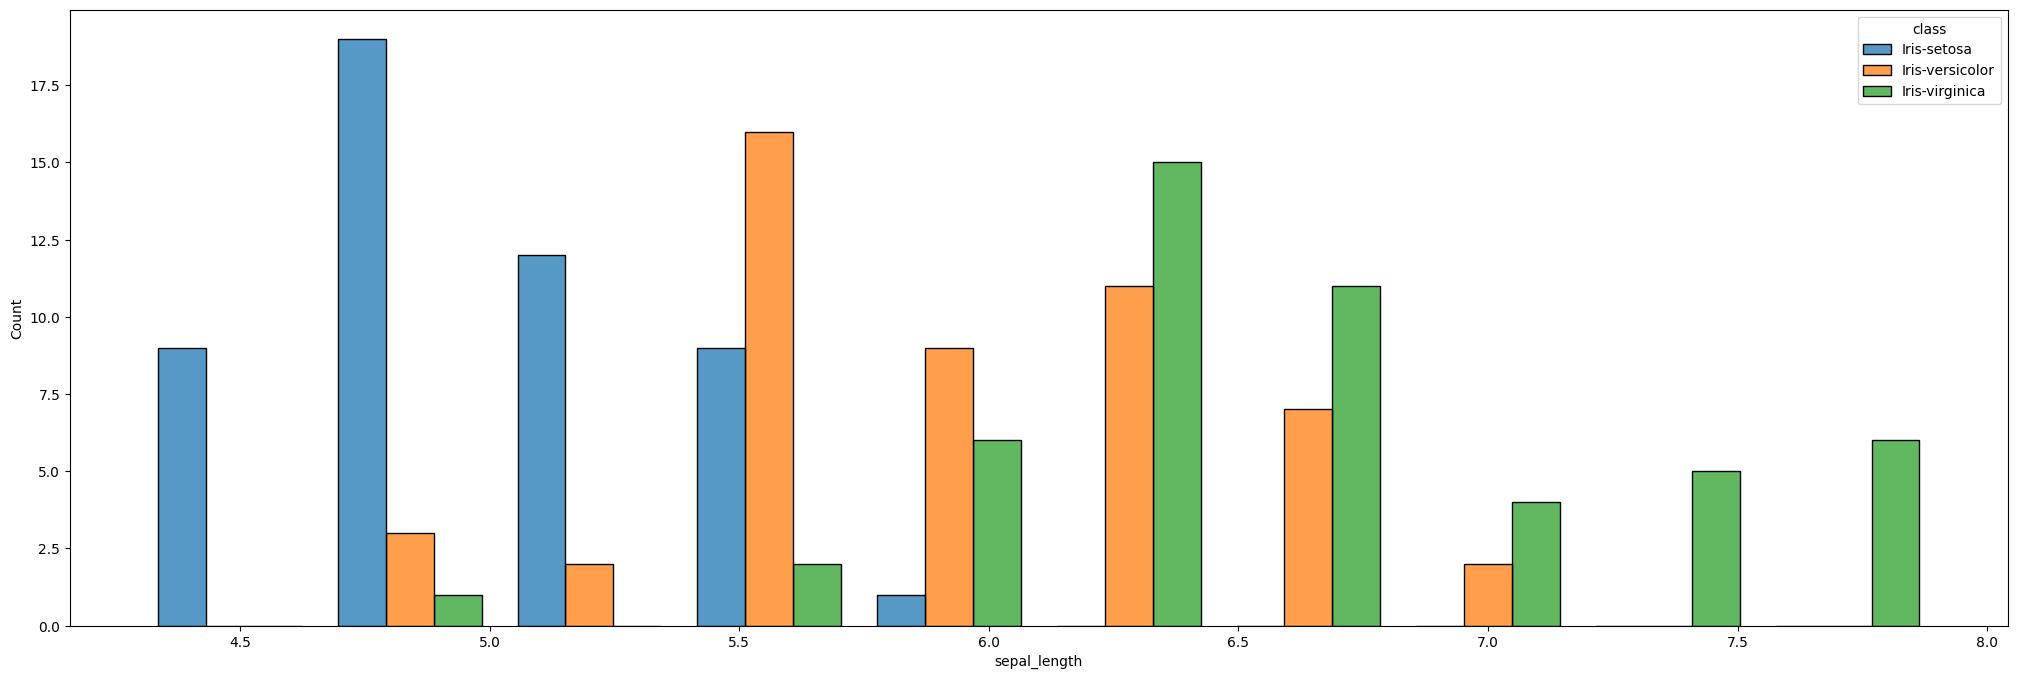

In [5]:
# multiple classes data based histogram
x \
    .extend_class(graph_ext.VisualDF).histogram("sepal_length", "class", yfigsize = 8)

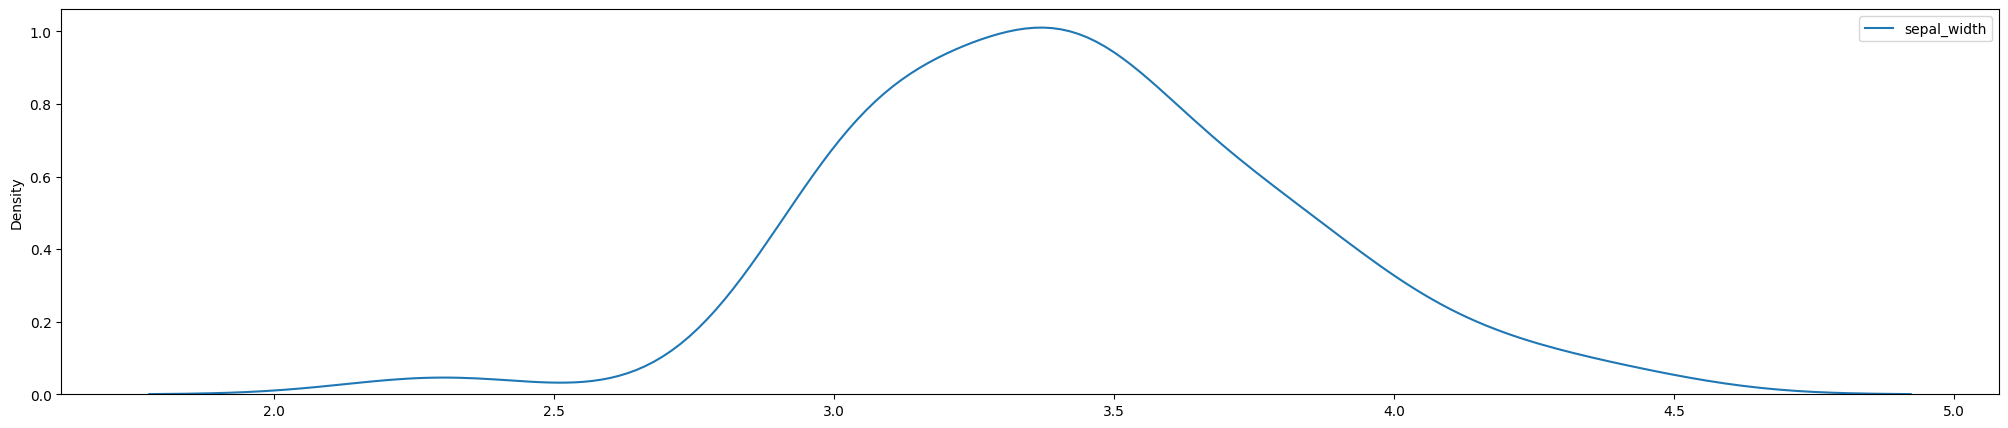

In [6]:
# density plot
x \
    .eq_str("class", "Iris-setosa") \
    .extend_class(graph_ext.VisualDF).density("sepal_width")

[WARN]: aggregate: builtin function used that has side effect. Please use udfs.* functions


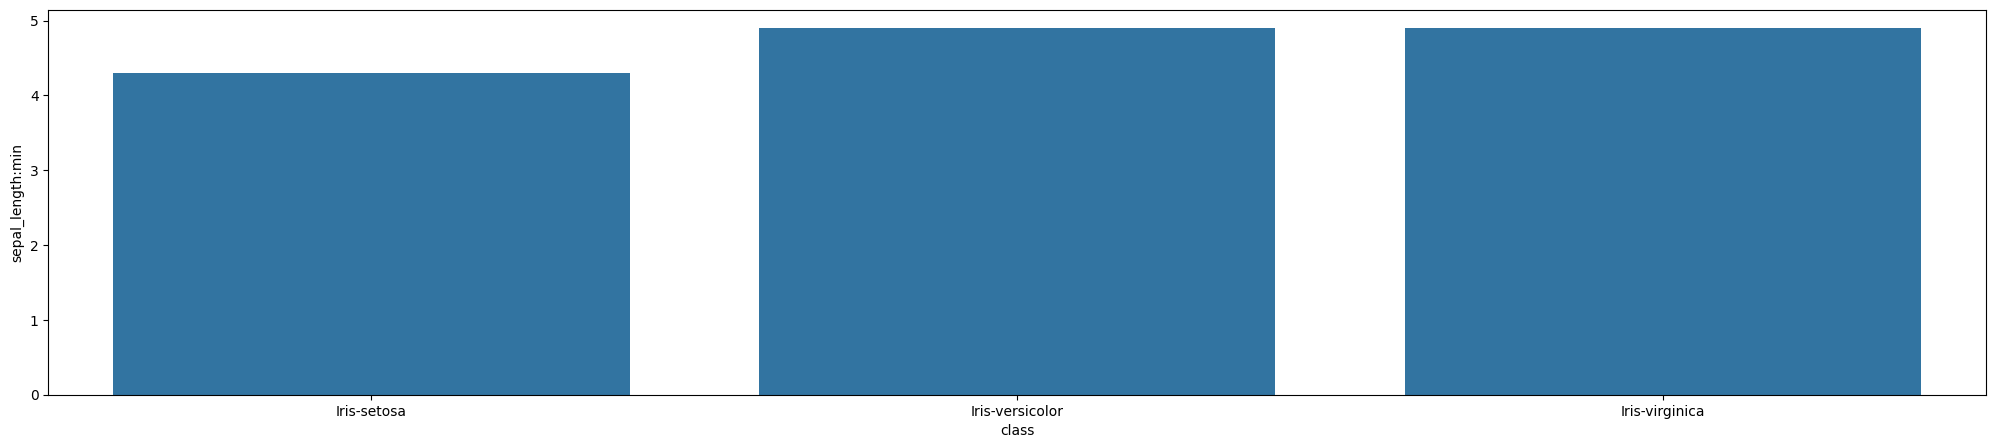

In [7]:
# compute simple statistics and use it for visualization. Note the naming convension of appending aggregate function
# name as suffix for the resultant column
x \
    .aggregate("class", ["sepal_length"], [min]) \
    .extend_class(graph_ext.VisualDF).barchart("class", "sepal_length:min")

[WARN ONCE ONLY]: Deprecated is_float_col


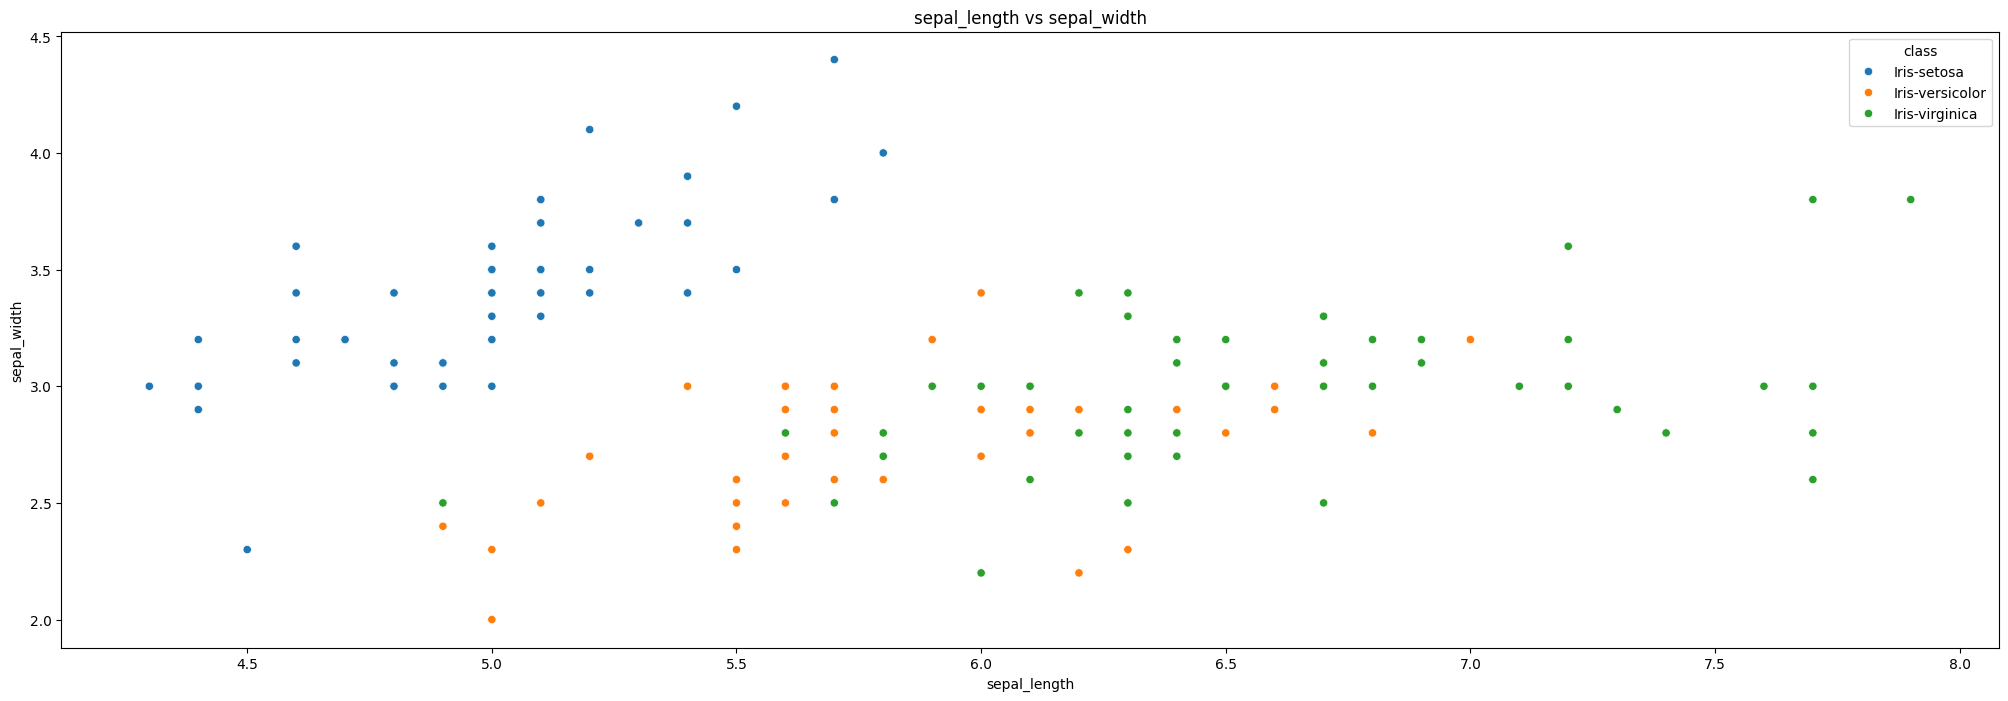

In [8]:
# scatter plot to see relationships between different attributes
x.extend_class(graph_ext.VisualDF).scatterplot("sepal_length", "sepal_width", "class", yfigsize = 8)

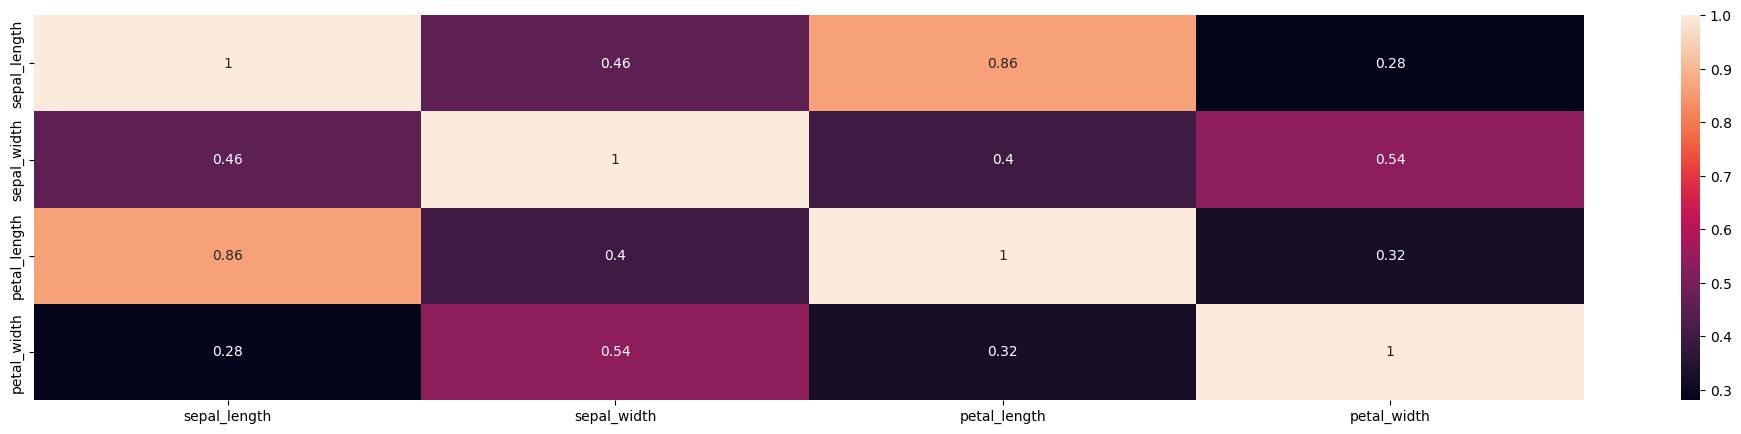

In [9]:
# correlation heatmap for finding correlation between lot of attributes
x \
    .eq_str("class", "Iris-virginica") \
    .extend_class(graph_ext.VisualDF).corr_heatmap(["sepal_length", "sepal_width", "petal_length", "petal_width"])

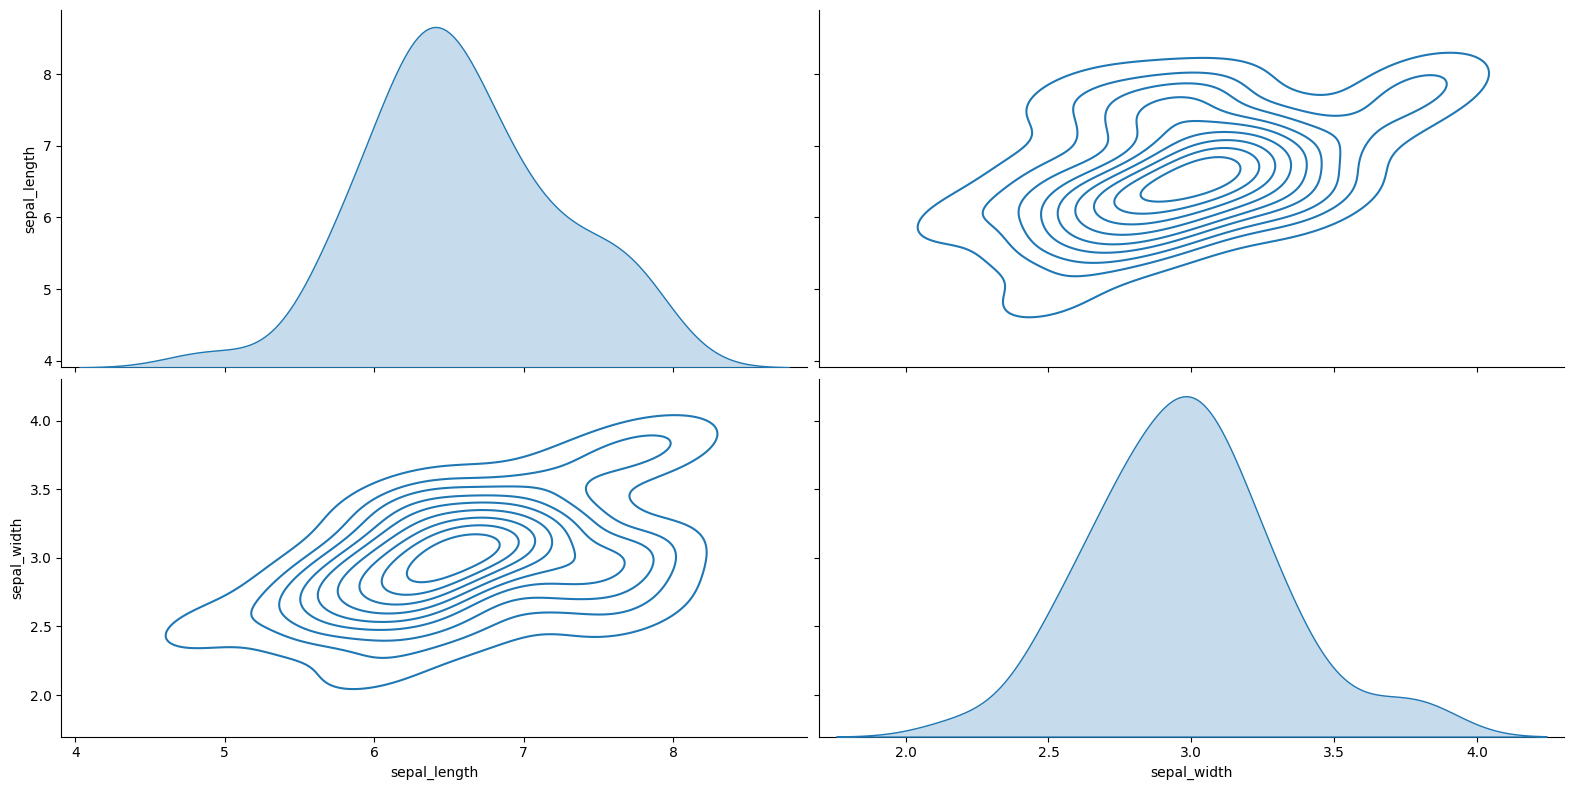

In [10]:
x \
    .eq_str("class", "Iris-virginica") \
    .extend_class(graph_ext.VisualDF).pairplot(["sepal_length", "sepal_width"], xfigsize = 8, yfigsize = 4,
        props = dict(kind = "kde", diag_kind = "auto"))